In [19]:
import tensorflow as tf
print(tf.__version__)
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, Activation, Input

2.18.0


In [20]:
data = pd.read_csv("/car_data.csv")
data.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [21]:
df = data.drop(['Unnamed: 0', 'New_Price'],axis=1)
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 564.4+ KB


In [23]:
data = df[["Kilometers_Driven","Year","Seats","Price"]]
h = data.corr(numeric_only=True)
h

,Kilometers_Driven,Year,Seats,Price
Kilometers_Driven,1.000000,-0.173048,0.083113,-0.011493
Year,-0.173048,1.000000,0.012333,0.305327
Seats,0.083113,0.012333,1.000000,0.052225
Price,-0.011493,0.305327,0.052225,1.000000


<Axes: >

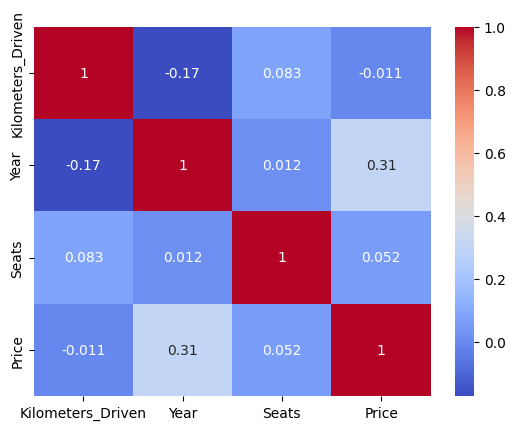

In [24]:
sns.heatmap(h, annot = True, cmap = "coolwarm")

<Axes: xlabel='Price', ylabel='Count'>

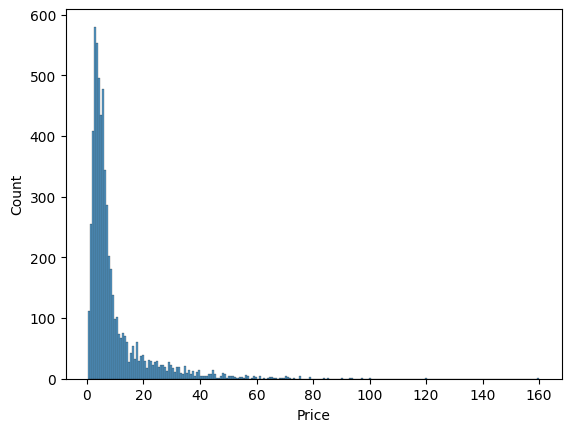

In [25]:
sns.histplot(x='Price', data=data)

In [26]:
numerical = df.drop(['Name','Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine', 'Mileage', 'Power'], axis = 1)
numerical.head()

,Year,Kilometers_Driven,Seats,Price
0,2010,72000,5.0,1.75
1,2015,41000,5.0,12.50
2,2011,46000,5.0,4.50
3,2012,87000,7.0,6.00
4,2013,40670,5.0,17.74


In [27]:
categorical = df[['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine', 'Mileage', 'Power']]
categorical.head()

,Location,Fuel_Type,Transmission,Owner_Type,Engine,Mileage,Power
0,Mumbai,CNG,Manual,First,998 CC,26.6 km/kg,58.16 bhp
1,Pune,Diesel,Manual,First,1582 CC,19.67 kmpl,126.2 bhp
2,Chennai,Petrol,Manual,First,1199 CC,18.2 kmpl,88.7 bhp
3,Chennai,Diesel,Manual,First,1248 CC,20.77 kmpl,88.76 bhp
4,Coimbatore,Diesel,Automatic,Second,1968 CC,15.2 kmpl,140.8 bhp


In [28]:
cat_numerical = pd.get_dummies(categorical, drop_first = True, dtype = int)
cat_numerical.head()

,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,...,Power_97.6 bhp,Power_97.7 bhp,Power_98.59 bhp,Power_98.6 bhp,Power_98.79 bhp,Power_98.82 bhp,Power_98.96 bhp,Power_99 bhp,Power_99.6 bhp,Power_null bhp
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
car_data = pd.concat([numerical, cat_numerical], axis = 1)
car_data.head()

,Year,Kilometers_Driven,Seats,Price,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,...,Power_97.6 bhp,Power_97.7 bhp,Power_98.59 bhp,Power_98.6 bhp,Power_98.79 bhp,Power_98.82 bhp,Power_98.96 bhp,Power_99 bhp,Power_99.6 bhp,Power_null bhp
0,2010,72000,5.0,1.75,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2015,41000,5.0,12.50,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2011,46000,5.0,4.50,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2012,87000,7.0,6.00,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2013,40670,5.0,17.74,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
car_data.dropna(inplace=True)

In [31]:
X = car_data.drop(['Price'], axis=1).values
y = car_data["Price"].values

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale the Data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [33]:
def create_model(learning_rate, dropout_rate):

    input_layer = Input(shape=(X.shape[1],))
    dense_layer0 = Dense(100, activation='relu')(input_layer)
    dense_layer1 = Dense(50, activation='relu')(dense_layer0)
    dense_layer2 = Dense(25, activation='relu')(dense_layer1)
    dense_layer3 = Dense(10, activation='relu')(dense_layer2)
    dense_layer4 = Dense(5, activation='relu')(dense_layer3)
    dense_layer5 = Dense(2, activation='relu')(dense_layer4)
    output = Dense(1)(dense_layer5)

    model = Model(inputs=input_layer, outputs=output)

    adam = Adam(learning_rate)
    model.compile(loss="mean_absolute_error", optimizer="adam", metrics=['mean_absolute_error'])

    return model

In [34]:
dropout_rate = 0.1
epochs = 5
batch_size = 5
learn_rate = 0.001

model = create_model(learn_rate, dropout_rate)

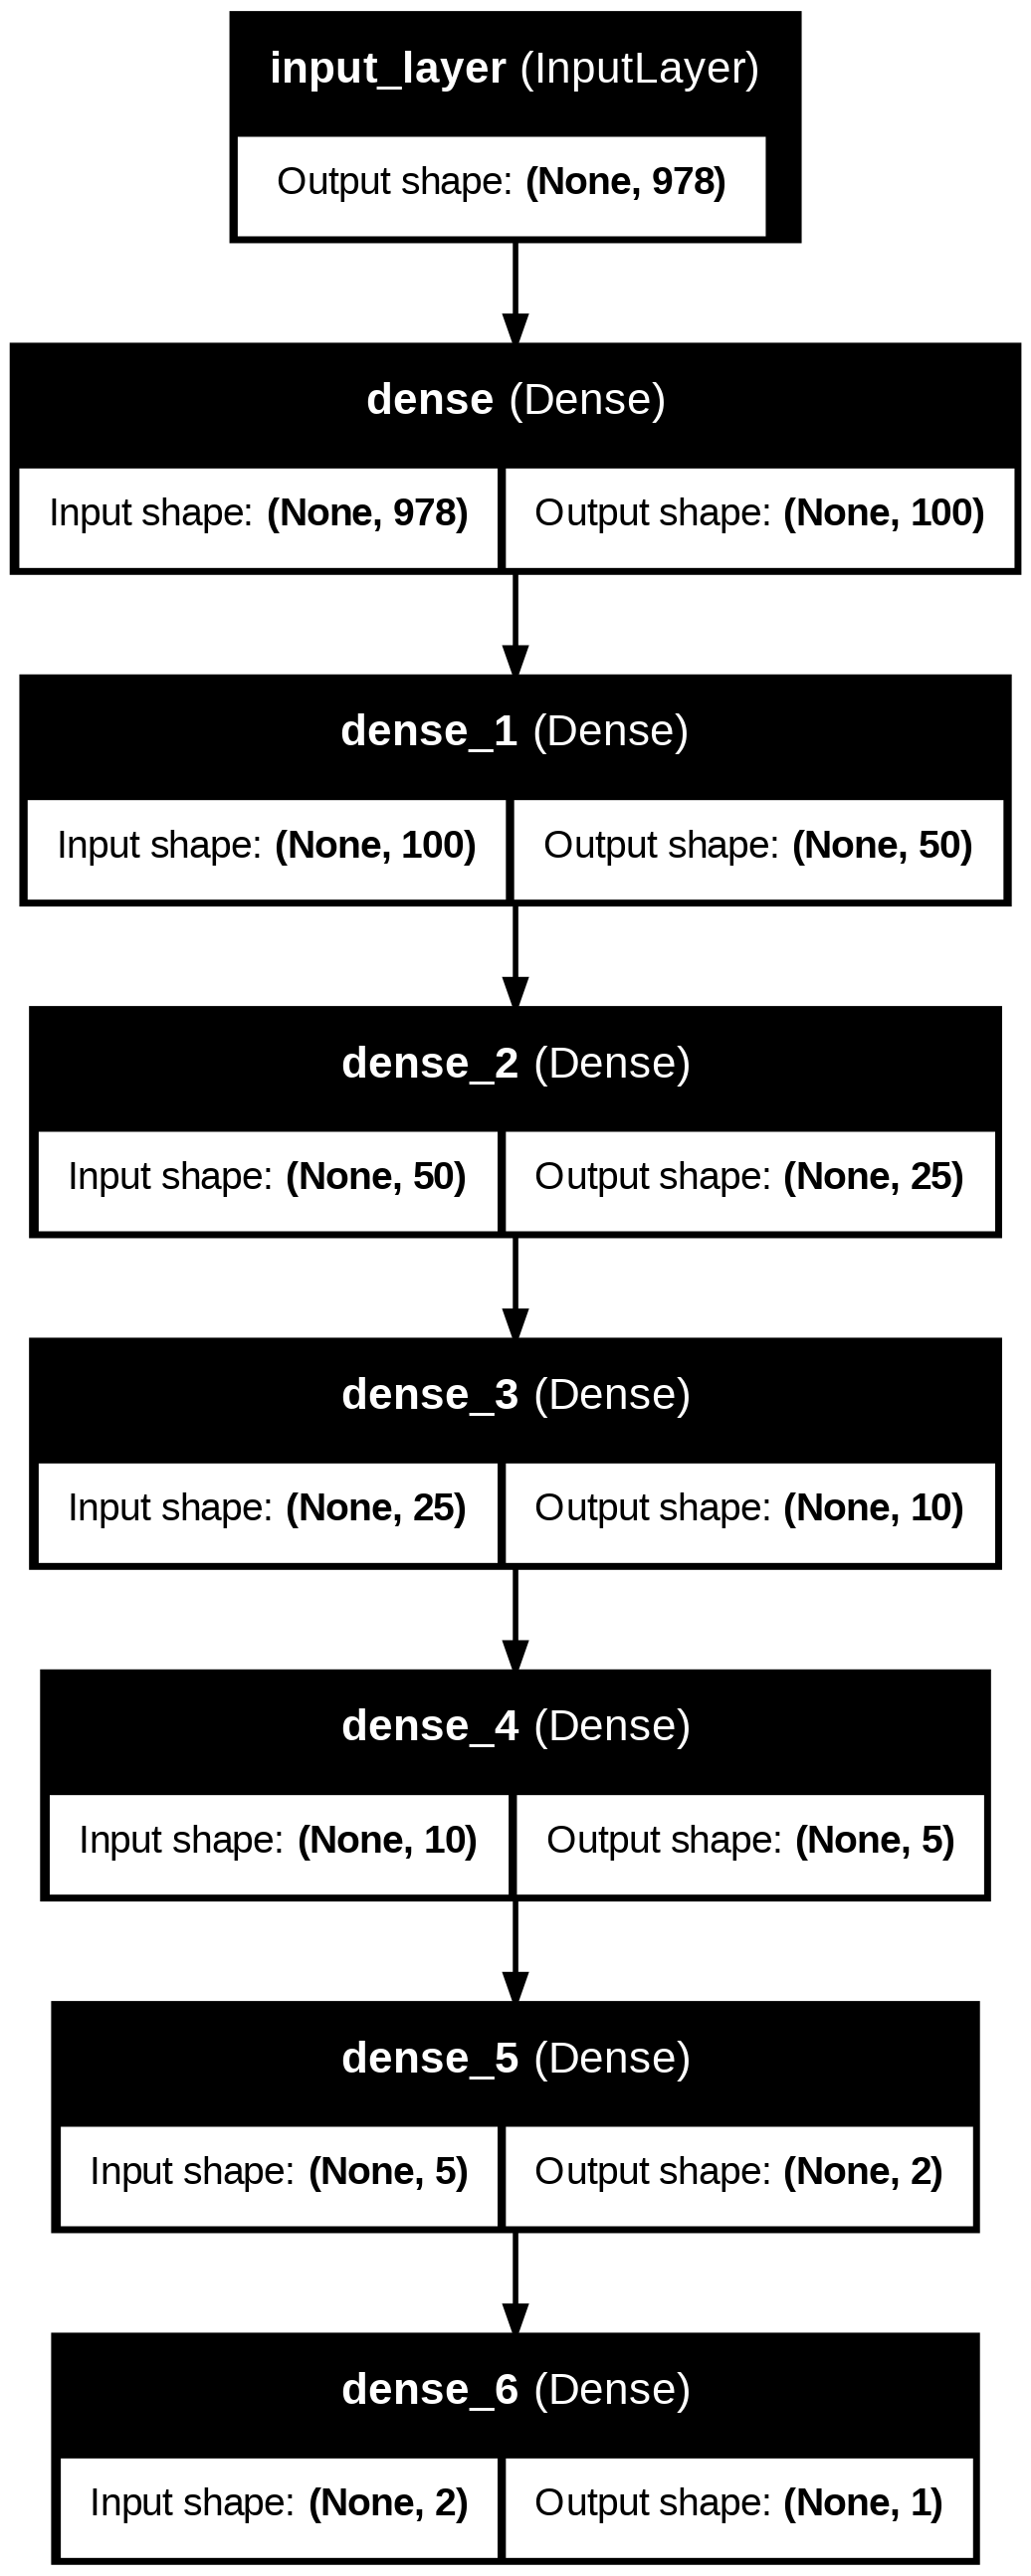

In [35]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot1.png', show_shapes=True, show_layer_names=True)

In [36]:
model_history = model.fit(X_train, y_train,
batch_size=batch_size, epochs=epochs, validation_split=0.2,
verbose=1)

Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5.1192 - mean_absolute_error: 5.1192 - val_loss: 2.3373 - val_mean_absolute_error: 2.3373
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.0837 - mean_absolute_error: 2.0837 - val_loss: 2.1768 - val_mean_absolute_error: 2.1768
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 1.7594 - mean_absolute_error: 1.7594 - val_loss: 2.2423 - val_mean_absolute_error: 2.2423
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.5464 - mean_absolute_error: 1.5464 - val_loss: 1.9736 - val_mean_absolute_error: 1.9736
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.3951 - mean_absolute_error: 1.3951 - val_loss: 2.0014 - val_mean_absolute_error: 2.0014


In [37]:
accuracies = model.evaluate(X_test, y_test, verbose=1)
print("Test Score:", accuracies[0])
print("Test Accuracy:", accuracies[1])

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0283 - mean_absolute_error: 2.0283
Test Score: 2.1700644493103027
Test Accuracy: 2.1700644493103027


dict_keys(['loss', 'mean_absolute_error', 'val_loss', 'val_mean_absolute_error'])


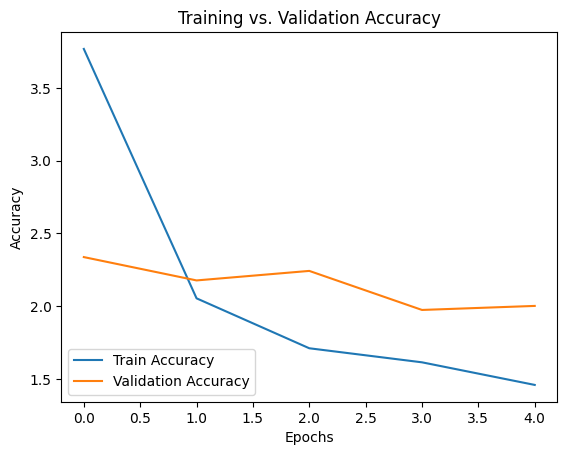

In [43]:
# Let's now plot the accuracy on the training and test sets
# to see if our model is overfitting.

history_dict = model_history.history
print(history_dict.keys())  # Check available metrics

import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(model_history.history['mean_absolute_error'], label='Train Accuracy')
plt.plot(model_history.history['val_mean_absolute_error'], label='Validation Accuracy')

plt.legend(loc='lower left')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.show()


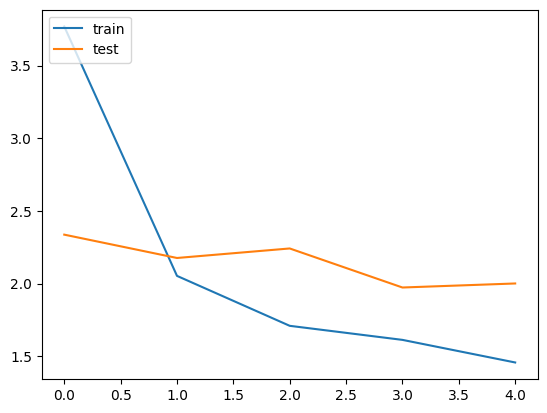

In [42]:
plt.plot(model_history.history['loss'], label = 'loss')
plt.plot(model_history.history['val_loss'], label = 'val_loss')
plt.legend(['train','test'], loc='upper left')

In [44]:
y_pred = model.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [45]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 2.1700642904110974
Mean Squared Error: 25.412515684585244
Root Mean Squared Error: 5.04108278890411


In [46]:
car_data['Price'].mean()

9.502775639953153

In [48]:
comparison_df = pd.DataFrame({'Actual': y_test.tolist(), 'Predicted': y_pred.tolist()})
comparison_df

,Actual,Predicted
0,4.70,[3.9509055614471436]
1,4.65,[3.662912368774414]
2,6.16,[7.050880432128906]
3,24.68,[24.88483238220215]
4,23.50,[23.124061584472656]
...,...,...
1191,1.45,[1.2804975509643555]
1192,2.45,[2.0597360134124756]
1193,3.50,[4.222575664520264]
1194,1.65,[1.962183952331543]


In [49]:
single_point = X_test[1].reshape(1,-1)
single_point.shape

(1, 978)

In [50]:
model.predict(X_test[1].reshape(1,-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[3.6629124]], dtype=float32)

In [52]:
y_test[1]

4.65